In [ ]:
#Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from scipy import stats
import os

# Getting the data

Dataset download link: https://www.kaggle.com/datasets/muhammetvarl/laptop-price/data

In [ ]:
df = pd.read_csv("\contents\laptop_price.csv", encoding='latin-1')

Dataset URL: https://www.kaggle.com/datasets/muhammetvarl/laptop-price


# Take a Quick Look at the Data Structure

In [ ]:
#Reading first 5 records of data
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [ ]:
# Number of rows and columns
df.shape

(1303, 13)

In [ ]:
# info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [ ]:
df["Company"].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
Fujitsu        3
Google         3
LG             3
Huawei         2
Name: count, dtype: int64

In [ ]:
# Statistical description of numerical data
numeric_df= df.select_dtypes(include=['int64', 'float64'])
numeric_df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [ ]:
# Statistical description of categorical data
categorical_df= df.select_dtypes(include=['object'])
categorical_df.describe()

,Company,Product,TypeName,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
count,1303,1303,1303,1303,1303,1303,1303,1303,1303,1303
unique,19,618,6,40,118,9,39,110,9,179
top,Dell,XPS 13,Notebook,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg
freq,297,30,727,507,190,619,412,281,1072,121


# Data Preprocessing

## 1- Data Cleaning

In [ ]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [ ]:
df.shape

(1303, 13)

In [ ]:
# Number of null values in each column
df.isnull().sum()


laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [ ]:
#removing dups

def remove_dups(df):
    dups = df.duplicated().sum()
    if(dups):
        print(f'duplicated values: {df.duplicated().sum()}')
        df = df.drop_duplicates(inplace= True)
    else:
        print(f'There is 0 duplicates')
    return df

remove_dups(df)
df.duplicated().sum()


There is 0 duplicates


np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

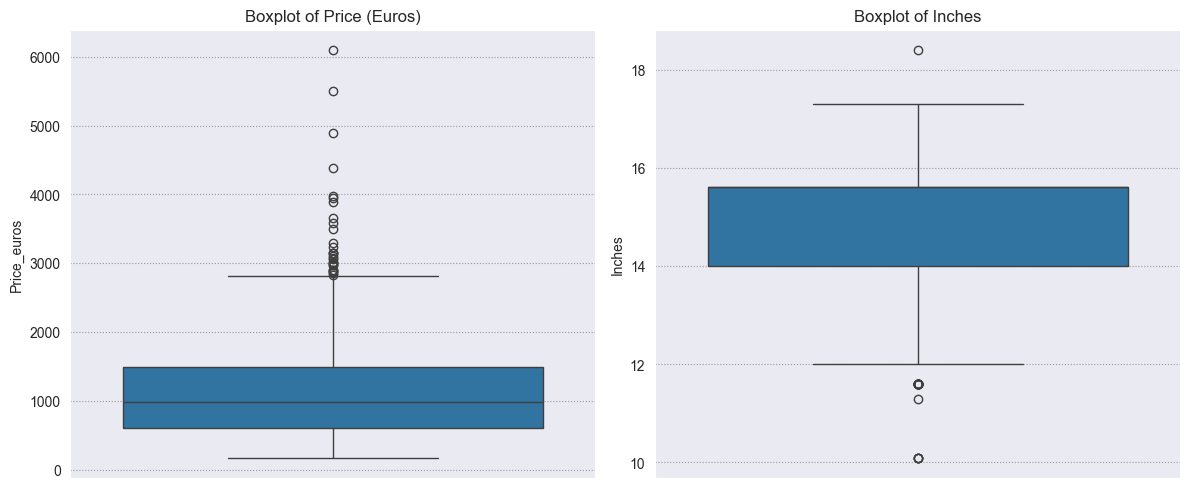

In [ ]:
#before
plt.figure(figsize=(12,5))

# Boxplot prices
plt.subplot(1,2,1)
sns.boxplot(y=df['Price_euros'])
plt.title('Boxplot of Price (Euros)')

# Boxplot inches
plt.subplot(1,2,2)
sns.boxplot(y=df['Inches'])
plt.title('Boxplot of Inches')

plt.tight_layout()
plt.show()


AS We see there is alot of outliers specially in the prices feature

In [ ]:
# Price
Q1 = df['Price_euros'].quantile(0.25)
Q3 = df['Price_euros'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df['Price_euros'] >= lower) & (df['Price_euros'] <= upper)]

# Inches
Q1_i = df['Inches'].quantile(0.25)
Q3_i = df['Inches'].quantile(0.75)
IQR_i = Q3_i - Q1_i
lower_i = Q1_i - 1.5*IQR_i
upper_i = Q3_i + 1.5*IQR_i

df = df[(df['Inches'] >= lower_i) & (df['Inches'] <= upper_i)]


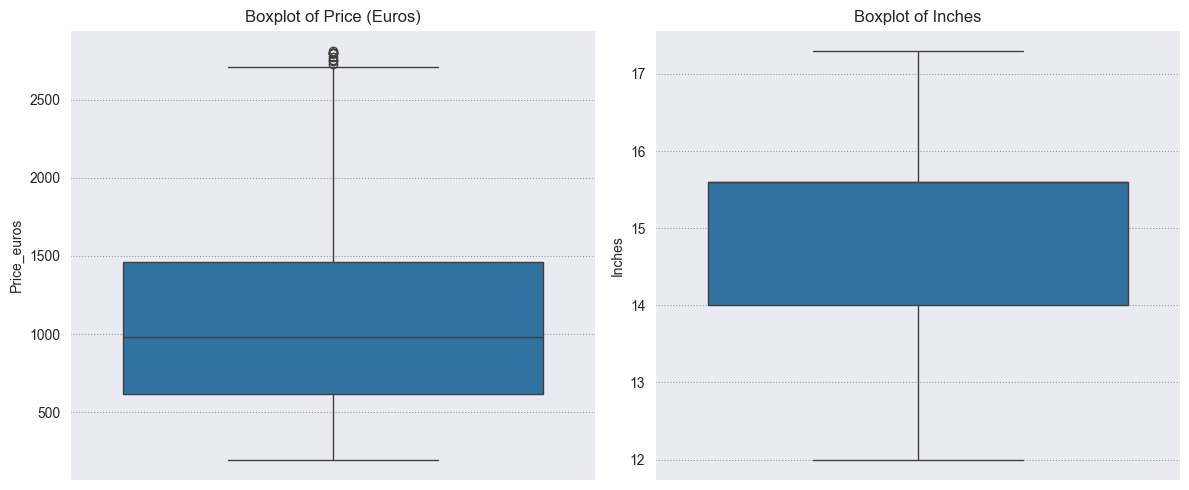

In [ ]:
#after
plt.figure(figsize=(12,5))

# Boxplot prices
plt.subplot(1,2,1)
sns.boxplot(y=df['Price_euros'])
plt.title('Boxplot of Price (Euros)')

# Boxplot inches
plt.subplot(1,2,2)
sns.boxplot(y=df['Inches'])
plt.title('Boxplot of Inches')

plt.tight_layout()
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1235 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1235 non-null   int64  
 1   Company           1235 non-null   object 
 2   Product           1235 non-null   object 
 3   TypeName          1235 non-null   object 
 4   Inches            1235 non-null   float64
 5   ScreenResolution  1235 non-null   object 
 6   Cpu               1235 non-null   object 
 7   Ram               1235 non-null   object 
 8   Memory            1235 non-null   object 
 9   Gpu               1235 non-null   object 
 10  OpSys             1235 non-null   object 
 11  Weight            1235 non-null   object 
 12  Price_euros       1235 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 135.1+ KB


In [ ]:
df['Weight'] = df['Weight'].str.replace('kg','').astype(float)

df['Ram'] = df['Ram'].str.replace('GB','').astype(int)

## 2-Feauture Engineering

In [ ]:
df["Cpu"].unique()

array(['Intel Core i5 2.3GHz', 'Intel Core i5 1.8GHz',
       'Intel Core i5 7200U 2.5GHz', 'Intel Core i7 2.7GHz',
       'Intel Core i5 3.1GHz', 'AMD A9-Series 9420 3GHz',
       'Intel Core i7 2.2GHz', 'Intel Core i7 8550U 1.8GHz',
       'Intel Core i5 8250U 1.6GHz', 'Intel Core i3 6006U 2GHz',
       'Intel Core i7 2.8GHz', 'Intel Core M m3 1.2GHz',
       'Intel Core i7 7500U 2.7GHz', 'Intel Core i3 7100U 2.4GHz',
       'Intel Core i5 7300HQ 2.5GHz', 'AMD E-Series E2-9000e 1.5GHz',
       'Intel Core i5 1.6GHz', 'Intel Core i7 8650U 1.9GHz',
       'Intel Atom x5-Z8300 1.44GHz', 'AMD E-Series E2-6110 1.5GHz',
       'AMD A6-Series 9220 2.5GHz',
       'Intel Celeron Dual Core N3350 1.1GHz',
       'Intel Core i3 7130U 2.7GHz', 'Intel Core i7 7700HQ 2.8GHz',
       'Intel Core i5 2.0GHz', 'AMD Ryzen 1700 3GHz',
       'Intel Pentium Quad Core N4200 1.1GHz',
       'Intel Celeron Dual Core N3060 1.6GHz', 'Intel Core i5 1.3GHz',
       'AMD FX 9830P 3GHz', 'Intel Core i7 7560U 2.4G

In [ ]:
def extract_cpu_info(cpu_string):
    parts_cpu = cpu_string.split()

    cpu_company=parts_cpu[0]
    cpu_type = ' '.join(parts_cpu[1:-1])
    frequency = parts_cpu[-1].replace('GHz', '')


    try:
        frequency = float(frequency)
    except ValueError:
        frequency = None

    return pd.Series([cpu_company, cpu_type, frequency])
df[['Cpu_Company','Cpu_Type', 'Cpu_Freq(GHz)']] = df['Cpu'].apply(extract_cpu_info)


In [ ]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Cpu_Company,Cpu_Type,Cpu_Freq(GHz)
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,Intel,Core i5,2.3
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,Intel,Core i5,1.8
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,Intel,Core i5 7200U,2.5
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,Intel,Core i7,2.7
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,Intel,Core i5,3.1


In [ ]:
df["Cpu_Type"].unique()

array(['Core i5', 'Core i5 7200U', 'Core i7', 'A9-Series 9420',
       'Core i7 8550U', 'Core i5 8250U', 'Core i3 6006U', 'Core M m3',
       'Core i7 7500U', 'Core i3 7100U', 'Core i5 7300HQ',
       'E-Series E2-9000e', 'Core i7 8650U', 'Atom x5-Z8300',
       'E-Series E2-6110', 'A6-Series 9220', 'Celeron Dual Core N3350',
       'Core i3 7130U', 'Core i7 7700HQ', 'Ryzen 1700',
       'Pentium Quad Core N4200', 'Celeron Dual Core N3060', 'FX 9830P',
       'Core i7 7560U', 'E-Series 6110', 'Core i5 6200U', 'Core M 6Y75',
       'Core i5 7500U', 'Core i5 7Y54', 'Core i7 6500U', 'E-Series 9000e',
       'A10-Series A10-9620P', 'A6-Series A6-9220', 'Core i7 6600U',
       'Celeron Dual Core 3205U', 'A10-Series 9600P', 'Core i7 7600U',
       'A8-Series 7410', 'Celeron Dual Core 3855U', 'A12-Series 9720P',
       'Core i5 7300U', 'Pentium Quad Core N3710', 'Core i5 6440HQ',
       'Core i7 6820HQ', 'Celeron Quad Core N3450', 'Core i7 7820HQ',
       'Core i7 7820HK', 'Ryzen 1600', 'Core

In [ ]:
df["Cpu_Type"].value_counts()

Cpu_Type
Core i5 7200U              193
Core i7 7700HQ             135
Core i7 7500U              134
Core i3 6006U               81
Core i7 8550U               73
                          ... 
A4-Series 7210               1
Core M 6Y54                  1
Pentium Dual Core 4405Y      1
E-Series 9000                1
Cortex A72&A53               1
Name: count, Length: 87, dtype: int64

In [ ]:
df["Cpu_Company"].value_counts()

Cpu_Company
Intel      1172
AMD          62
Samsung       1
Name: count, dtype: int64

In [ ]:
df[df['Cpu_Company']=='Samsung']

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Cpu_Company,Cpu_Type,Cpu_Freq(GHz)
1191,1209,Samsung,Chromebook Plus,2 in 1 Convertible,12.3,IPS Panel Touchscreen 2400x1600,Samsung Cortex A72&A53 2.0GHz,4,32GB Flash Storage,ARM Mali T860 MP4,Chrome OS,1.15,659.0,Samsung,Cortex A72&A53,2.0


In [ ]:
df=df.drop(1191)

In [ ]:
df["Gpu"].unique()

array(['Intel Iris Plus Graphics 640', 'Intel HD Graphics 6000',
       'Intel HD Graphics 620', 'AMD Radeon Pro 455',
       'Intel Iris Plus Graphics 650', 'AMD Radeon R5',
       'Intel Iris Pro Graphics', 'Nvidia GeForce MX150',
       'Intel UHD Graphics 620', 'Intel HD Graphics 520',
       'AMD Radeon Pro 555', 'AMD Radeon R5 M430',
       'Intel HD Graphics 615', 'Nvidia GeForce 940MX',
       'Nvidia GeForce GTX 1050', 'AMD Radeon R2', 'AMD Radeon 530',
       'Nvidia GeForce 930MX', 'Intel HD Graphics',
       'Intel HD Graphics 500', 'Nvidia GeForce 930MX ',
       'Nvidia GeForce GTX 1060', 'Nvidia GeForce 150MX',
       'Intel Iris Graphics 540', 'AMD Radeon RX 580',
       'Nvidia GeForce 920MX', 'AMD Radeon R4 Graphics', 'AMD Radeon 520',
       'Nvidia GeForce GTX 1070', 'Nvidia GeForce GTX 1050 Ti',
       'Intel HD Graphics 400', 'Nvidia GeForce MX130', 'AMD R4 Graphics',
       'Nvidia GeForce GTX 940MX', 'AMD Radeon RX 560',
       'Nvidia GeForce 920M', 'AMD Radeon

In [ ]:
# Define a function to extract the GPU information
def extract_GPU_info(df):
  df['Gpu_company'] = df['Gpu'].str.extract(r'^(\w+)')
  df['Gpu_Type']= df['Gpu'].str.replace(r'^(\w+)', '', regex=True)
  df.drop(columns=['Gpu'], inplace=True)
  return df


df = extract_GPU_info(df)

In [ ]:
df["Gpu_company"].value_counts()

Gpu_company
Intel     682
Nvidia    374
AMD       178
Name: count, dtype: int64

In [ ]:
df["Gpu_Type"].value_counts()

Gpu_Type
HD Graphics 620     280
HD Graphics 520     185
UHD Graphics 620     68
GeForce GTX 1050     66
GeForce GTX 1060     46
                   ... 
FirePro W4190M        1
Radeon R5 M315        1
Quadro M500M          1
Radeon R7 M360        1
GeForce 960M          1
Name: count, Length: 100, dtype: int64

In [ ]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,OpSys,Weight,Price_euros,Cpu_Company,Cpu_Type,Cpu_Freq(GHz),Gpu_company,Gpu_Type
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,macOS,1.37,1339.69,Intel,Core i5,2.3,Intel,Iris Plus Graphics 640
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,macOS,1.34,898.94,Intel,Core i5,1.8,Intel,HD Graphics 6000
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,No OS,1.86,575.00,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,macOS,1.83,2537.45,Intel,Core i7,2.7,AMD,Radeon Pro 455
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,macOS,1.37,1803.60,Intel,Core i5,3.1,Intel,Iris Plus Graphics 650


In [ ]:
df['Memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '128GB SSD +  1TB HDD', '256GB SSD +  256GB SSD',
       '64GB Flash Storage', '32GB Flash Storage', '256GB SSD +  1TB HDD',
       '256GB SSD +  2TB HDD', '32GB SSD', '2TB HDD', '64GB SSD',
       '1.0TB Hybrid', '512GB SSD +  1TB HDD', '256GB SSD +  500GB HDD',
       '128GB SSD +  2TB HDD', '512GB SSD +  512GB SSD', '16GB SSD',
       '1TB SSD', '16GB Flash Storage', '512GB SSD +  256GB SSD',
       '512GB SSD +  2TB HDD', '64GB Flash Storage +  1TB HDD',
       '180GB SSD', '1TB HDD +  1TB HDD', '32GB HDD',
       '512GB Flash Storage', '128GB HDD', '8GB SSD', '508GB Hybrid',
       '1.0TB HDD', '256GB SSD +  1.0TB Hybrid'], dtype=object)

In [ ]:
def extract_Memory_info(Memory_string):
    parts_memory = Memory_string.split('+')

    First_memory = parts_memory[0]

    if len(parts_memory) > 1:
        Second_memory = parts_memory[1].strip()
    else:
        Second_memory =  np.nan
    return pd.Series([First_memory, Second_memory])


df[['First_memory', 'Second_memory']] = df['Memory'].apply(extract_Memory_info)

In [ ]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,OpSys,Weight,Price_euros,Cpu_Company,Cpu_Type,Cpu_Freq(GHz),Gpu_company,Gpu_Type,First_memory,Second_memory
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,macOS,1.37,1339.69,Intel,Core i5,2.3,Intel,Iris Plus Graphics 640,128GB SSD,NaN
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,macOS,1.34,898.94,Intel,Core i5,1.8,Intel,HD Graphics 6000,128GB Flash Storage,NaN
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,No OS,1.86,575.00,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,256GB SSD,NaN
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,macOS,1.83,2537.45,Intel,Core i7,2.7,AMD,Radeon Pro 455,512GB SSD,NaN
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,macOS,1.37,1803.60,Intel,Core i5,3.1,Intel,Iris Plus Graphics 650,256GB SSD,NaN


In [ ]:
new_order = ['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution',
             'Cpu_Company', 'Cpu_Type', 'Cpu_Freq(GHz)', 'Ram', 'First_memory','Second_memory',
             'Gpu_company','Gpu_Type', 'OpSys', 'Weight','Price_euros']
df = df[new_order]
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu_Company,Cpu_Type,Cpu_Freq(GHz),Ram,First_memory,Second_memory,Gpu_company,Gpu_Type,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,NaN,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,NaN,Intel,HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,NaN,Intel,HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,NaN,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,NaN,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [ ]:
df['First_memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD', '128GB SSD ',
       '256GB SSD ', '64GB Flash Storage', '32GB Flash Storage',
       '32GB SSD', '2TB HDD', '64GB SSD', '1.0TB Hybrid', '512GB SSD ',
       '16GB SSD', '1TB SSD', '16GB Flash Storage', '64GB Flash Storage ',
       '180GB SSD', '1TB HDD ', '32GB HDD', '512GB Flash Storage',
       '128GB HDD', '8GB SSD', '508GB Hybrid', '1.0TB HDD'], dtype=object)

In [ ]:
df['Second_memory'].unique()

array([nan, '1TB HDD', '256GB SSD', '2TB HDD', '500GB HDD', '512GB SSD',
       '1.0TB Hybrid'], dtype=object)

In [ ]:
def extract_fMemory_info(fMemory_string):
    fparts_memory = fMemory_string.split()

    First_memory_volume = fparts_memory[0]
    First_memory_type = ' '.join(fparts_memory[1:])
    return pd.Series([First_memory_volume, First_memory_type])

df[['First_memory_volume', 'First_memory_type']] = df['First_memory'].apply(extract_fMemory_info)

def extract_SMemory_info(SMemory_string):
    if pd.isna(SMemory_string):
        return pd.Series([np.nan, np.nan])

    Sparts_memory = SMemory_string.split()
    Second_memory_volume = Sparts_memory[0]
    Second_memory_type = ' '.join(Sparts_memory[1:])
    return pd.Series([Second_memory_volume, Second_memory_type])
df[['Second_memory_volume', 'Second_memory_type']] = df['Second_memory'].apply(extract_SMemory_info)


In [ ]:
new_order = ['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution',
             'Cpu_Company', 'Cpu_Type', 'Cpu_Freq(GHz)', 'Ram', 'First_memory_volume','First_memory_type','Second_memory_volume',
            'Second_memory_type', 'Gpu_company','Gpu_Type', 'OpSys', 'Weight','Price_euros']
df = df[new_order]
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu_Company,Cpu_Type,Cpu_Freq(GHz),Ram,First_memory_volume,First_memory_type,Second_memory_volume,Second_memory_type,Gpu_company,Gpu_Type,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB,SSD,NaN,NaN,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB,Flash Storage,NaN,NaN,Intel,HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB,SSD,NaN,NaN,Intel,HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB,SSD,NaN,NaN,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB,SSD,NaN,NaN,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1234 entries, 0 to 1302
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   laptop_ID             1234 non-null   int64  
 1   Company               1234 non-null   object 
 2   Product               1234 non-null   object 
 3   TypeName              1234 non-null   object 
 4   Inches                1234 non-null   float64
 5   ScreenResolution      1234 non-null   object 
 6   Cpu_Company           1234 non-null   object 
 7   Cpu_Type              1234 non-null   object 
 8   Cpu_Freq(GHz)         1234 non-null   float64
 9   Ram                   1234 non-null   int64  
 10  First_memory_volume   1234 non-null   object 
 11  First_memory_type     1234 non-null   object 
 12  Second_memory_volume  196 non-null    object 
 13  Second_memory_type    196 non-null    object 
 14  Gpu_company           1234 non-null   object 
 15  Gpu_Type              1234

In [ ]:
df['Second_memory_volume'].unique()

array([nan, '1TB', '256GB', '2TB', '500GB', '512GB', '1.0TB'],
      dtype=object)

In [ ]:
df['Second_memory_type'].unique()

array([nan, 'HDD', 'SSD', 'Hybrid'], dtype=object)

In [ ]:
df['Second_memory_type'].isnull().sum()


np.int64(1038)

:-Due to the high number of missing values because not all laptops have a secondary hard drive, We will be dropping this column

In [ ]:
df.drop(columns = ['Second_memory_type'], inplace = True)

In [ ]:
def convert_to_gb1(First_memory_value):
    if 'TB' in First_memory_value:
        return float(First_memory_value.replace('TB', '').strip()) * 1024
    if 'GB' in First_memory_value:
        return float(First_memory_value.replace('GB', '').strip())
    return None

def convert_to_gb2(Second_memory_value):
    if  pd.isna(Second_memory_value):
        return 0.0
    if 'TB' in Second_memory_value:
        return float(Second_memory_value.replace('TB', '').strip()) * 1024
    if 'GB' in Second_memory_value:
        return float(Second_memory_value.replace('GB', '').strip())
    return None

df['First_memory_volume'] = df['First_memory_volume'].apply(convert_to_gb1)
df['Second_memory_volume'] = df['Second_memory_volume'].apply(convert_to_gb2)
df.rename(columns={ 'First_memory_volume' :'First_memory_volume(GB)', 'Second_memory_volume' :'Second_memory_volume(GB)'}, inplace=True)

In [ ]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu_Company,Cpu_Type,Cpu_Freq(GHz),Ram,First_memory_volume(GB),First_memory_type,Second_memory_volume(GB),Gpu_company,Gpu_Type,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128.0,SSD,0.0,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128.0,Flash Storage,0.0,Intel,HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256.0,SSD,0.0,Intel,HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512.0,SSD,0.0,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256.0,SSD,0.0,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1234 entries, 0 to 1302
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   laptop_ID                 1234 non-null   int64  
 1   Company                   1234 non-null   object 
 2   Product                   1234 non-null   object 
 3   TypeName                  1234 non-null   object 
 4   Inches                    1234 non-null   float64
 5   ScreenResolution          1234 non-null   object 
 6   Cpu_Company               1234 non-null   object 
 7   Cpu_Type                  1234 non-null   object 
 8   Cpu_Freq(GHz)             1234 non-null   float64
 9   Ram                       1234 non-null   int64  
 10  First_memory_volume(GB)   1234 non-null   float64
 11  First_memory_type         1234 non-null   object 
 12  Second_memory_volume(GB)  1234 non-null   float64
 13  Gpu_company               1234 non-null   object 
 14  Gpu_Type     

In [ ]:
df["ScreenResolution"].unique()

array(['IPS Panel Retina Display 2560x1600', '1440x900',
       'Full HD 1920x1080', 'IPS Panel Retina Display 2880x1800',
       '1366x768', 'IPS Panel Full HD 1920x1080',
       'IPS Panel Retina Display 2304x1440',
       'IPS Panel Full HD / Touchscreen 1920x1080',
       'Full HD / Touchscreen 1920x1080',
       'Touchscreen / Quad HD+ 3200x1800', 'Touchscreen 2256x1504',
       'Quad HD+ / Touchscreen 3200x1800', 'IPS Panel 1366x768',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD 2160x1440',
       '4K Ultra HD / Touchscreen 3840x2160', '1600x900',
       'IPS Panel 4K Ultra HD 3840x2160', 'Touchscreen 1366x768',
       'Touchscreen 2560x1440', 'IPS Panel Full HD 1366x768',
       'IPS Panel 2560x1440', 'IPS Panel Full HD 2560x1440',
       'IPS Panel Retina Display 2736x1824', 'Touchscreen 2400x1600',
       '2560x1440', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel Quad HD+ 3200x1800',
       'IPS Panel Quad HD+ / Touchscreen 3200x1800',


In [ ]:
#  extract the screen information

def extract_screen_information(df):
  df['Resolution'] = df['ScreenResolution'].str.extract(r'(\d+x\d+)')
  df['Screentype'] = df['ScreenResolution'].replace(r'(\d+x\d+)','',regex=True)
  df['Screentype'] = df['Screentype'].replace(r'(Full HD|Quad HD|Quad HD|\+|/|4K Ultra HD)','',regex=True)
  df['Touchscreen'] = df['Screentype'].str.extract(r'(Touchscreen)')
  df['Screentype'] = df['Screentype'].replace(r'(Touchscreen)','',regex=True)
  df['Touchscreen'] = df['Touchscreen'].replace('Touchscreen',1)
  df['Touchscreen'] = df['Touchscreen'].replace(np.nan,0)
  df['Screentype']=df['Screentype'].replace(r' ','',regex=True)
  df['Screentype'] = df['Screentype'].replace(r'^\s*$', np.nan, regex=True)
  df = df.drop('ScreenResolution', axis=1)

  #move label feature to the end
  df = df[[col for col in df.columns if col != 'Price_euros'] + ['Price_euros']]

  return df
df = extract_screen_information(df)

C:\Users\Amr\AppData\Local\Temp\ipykernel_20160\1587480832.py:9: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [ ]:
df['Screentype'].isnull().sum()

np.int64(899)

-Due to the high number of missing values because not all laptops include their screen type, We will be dropping this column

In [ ]:
df.drop(columns = ['Screentype'], inplace = True)

In [ ]:
df['Resolution'].unique()

array(['2560x1600', '1440x900', '1920x1080', '2880x1800', '1366x768',
       '2304x1440', '3200x1800', '2256x1504', '3840x2160', '2160x1440',
       '1600x900', '2560x1440', '2736x1824', '2400x1600', '1920x1200'],
      dtype=object)

In [ ]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,Cpu_Company,Cpu_Type,Cpu_Freq(GHz),Ram,First_memory_volume(GB),First_memory_type,Second_memory_volume(GB),Gpu_company,Gpu_Type,OpSys,Weight,Resolution,Touchscreen,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,Intel,Core i5,2.3,8,128.0,SSD,0.0,Intel,Iris Plus Graphics 640,macOS,1.37,2560x1600,0.0,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,Intel,Core i5,1.8,8,128.0,Flash Storage,0.0,Intel,HD Graphics 6000,macOS,1.34,1440x900,0.0,898.94
2,3,HP,250 G6,Notebook,15.6,Intel,Core i5 7200U,2.5,8,256.0,SSD,0.0,Intel,HD Graphics 620,No OS,1.86,1920x1080,0.0,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,Intel,Core i7,2.7,16,512.0,SSD,0.0,AMD,Radeon Pro 455,macOS,1.83,2880x1800,0.0,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,Intel,Core i5,3.1,8,256.0,SSD,0.0,Intel,Iris Plus Graphics 650,macOS,1.37,2560x1600,0.0,1803.60


In [ ]:
df['laptop_ID']

0          1
1          2
2          3
3          4
4          5
        ... 
1298    1316
1299    1317
1300    1318
1301    1319
1302    1320
Name: laptop_ID, Length: 1234, dtype: int64

The laptop_id doesn't correctly represent the order of laptop in df,  We can use pandas index instead so we will drop it


In [ ]:
df.drop(columns=['laptop_ID'], inplace=True)
df.head()

,Company,Product,TypeName,Inches,Cpu_Company,Cpu_Type,Cpu_Freq(GHz),Ram,First_memory_volume(GB),First_memory_type,Second_memory_volume(GB),Gpu_company,Gpu_Type,OpSys,Weight,Resolution,Touchscreen,Price_euros
0,Apple,MacBook Pro,Ultrabook,13.3,Intel,Core i5,2.3,8,128.0,SSD,0.0,Intel,Iris Plus Graphics 640,macOS,1.37,2560x1600,0.0,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,Intel,Core i5,1.8,8,128.0,Flash Storage,0.0,Intel,HD Graphics 6000,macOS,1.34,1440x900,0.0,898.94
2,HP,250 G6,Notebook,15.6,Intel,Core i5 7200U,2.5,8,256.0,SSD,0.0,Intel,HD Graphics 620,No OS,1.86,1920x1080,0.0,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,Intel,Core i7,2.7,16,512.0,SSD,0.0,AMD,Radeon Pro 455,macOS,1.83,2880x1800,0.0,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,Intel,Core i5,3.1,8,256.0,SSD,0.0,Intel,Iris Plus Graphics 650,macOS,1.37,2560x1600,0.0,1803.60


In [ ]:
df['Product'].value_counts()

Product
XPS 13                                   30
Inspiron 3567                            29
250 G6                                   21
Vostro 3568                              19
Legion Y520-15IKBN                       19
                                         ..
X555BP-XX180T (A9-9420/4GB/1TB/Radeon     1
GE63VR 7RE                                1
17-bs001nv (i5-7200U/6GB/2TB/Radeon       1
V310-15IKB (i5-7200U/8GB/1TB              1
Inspiron 7779                             1
Name: count, Length: 578, dtype: int64

The Product contains an excessively large number of values, The model won't get many insights from the feature.

In [ ]:
df.drop(columns=['Product'], inplace=True)
df.head()

,Company,TypeName,Inches,Cpu_Company,Cpu_Type,Cpu_Freq(GHz),Ram,First_memory_volume(GB),First_memory_type,Second_memory_volume(GB),Gpu_company,Gpu_Type,OpSys,Weight,Resolution,Touchscreen,Price_euros
0,Apple,Ultrabook,13.3,Intel,Core i5,2.3,8,128.0,SSD,0.0,Intel,Iris Plus Graphics 640,macOS,1.37,2560x1600,0.0,1339.69
1,Apple,Ultrabook,13.3,Intel,Core i5,1.8,8,128.0,Flash Storage,0.0,Intel,HD Graphics 6000,macOS,1.34,1440x900,0.0,898.94
2,HP,Notebook,15.6,Intel,Core i5 7200U,2.5,8,256.0,SSD,0.0,Intel,HD Graphics 620,No OS,1.86,1920x1080,0.0,575.00
3,Apple,Ultrabook,15.4,Intel,Core i7,2.7,16,512.0,SSD,0.0,AMD,Radeon Pro 455,macOS,1.83,2880x1800,0.0,2537.45
4,Apple,Ultrabook,13.3,Intel,Core i5,3.1,8,256.0,SSD,0.0,Intel,Iris Plus Graphics 650,macOS,1.37,2560x1600,0.0,1803.60


## 3-Visualization and finding correlations

In [ ]:
import plotly.express as px

categorical_cols = [
    'Company', 'TypeName', 'Cpu_Company', 'Cpu_Type',
    'First_memory_type', 'Gpu_company', 'Gpu_Type',
    'OpSys', 'Resolution'
]

for col in categorical_cols:
    counts = df[col].value_counts().reset_index()
    counts.columns = [col, "count"]   # إعادة تسمية الأعمدة

    fig = px.bar(
        counts,
        x=col,
        y="count",
        color=col,
        title=f"Distribution of {col}",
        height=500
    )
    fig.update_layout(
        xaxis={'categoryorder': 'total descending'},
        showlegend=False
    )
    fig.show()


In [ ]:
import plotly.express as px

categorical_cols = [
    'Company', 'TypeName', 'Cpu_Company', 'Cpu_Type',
    'First_memory_type', 'Gpu_company', 'Gpu_Type',
    'OpSys', 'Resolution'
]

for col in categorical_cols:
    fig = px.bar(
        df,
        x=col,
        y='Price_euros',
        color=col,
        title=f"{col} vs Price",
        height=500
    )
    fig.update_layout(
        xaxis={'categoryorder':'total descending'},  # ترتيب حسب السعر
        showlegend=False
    )
    fig.show()


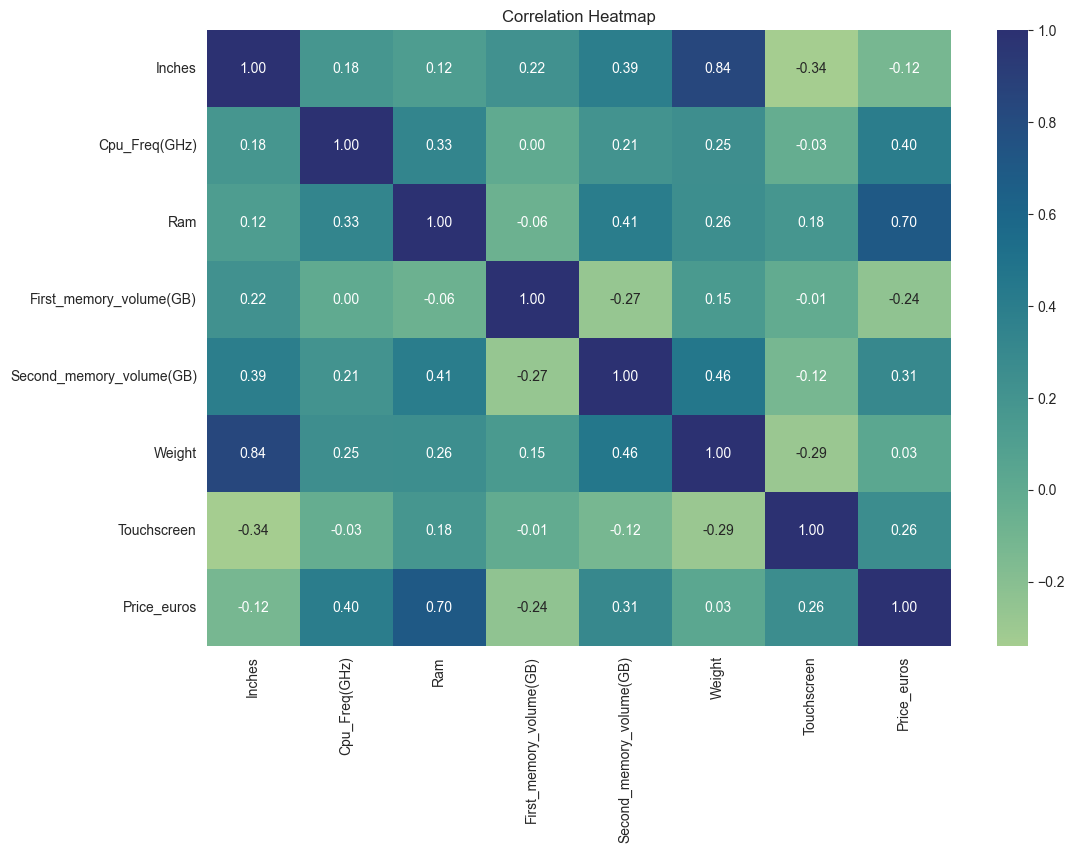

In [ ]:
# Specify only numeric columns
numerical_cols = df.select_dtypes(include=['number'])

# Correlation coefficient
correlation_matrix = numerical_cols.corr()

# heatmap to see the relationships.
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

We will drop the inches feature due to the high correlation coefficient and high positive linearity between it and the weight and the non linear relation between inches feature and the price

## 4- spiltting the data


In [ ]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2,random_state=42)
df = train_set.copy()

In [ ]:
print(len(train_set))
print(len(test_set))

987
247


## 5- Transforming the price label due to the skewness seen earlier

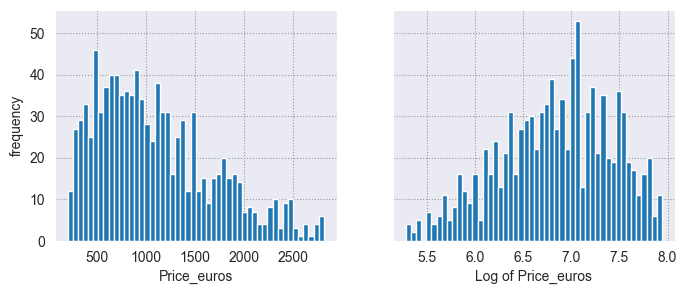

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
df["Price_euros"].hist(ax=axs[0], bins=50)
df["Price_euros"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Price_euros")
axs[1].set_xlabel("Log of Price_euros")
axs[0].set_ylabel("frequency")
plt.show()

In [ ]:
from sklearn.preprocessing import FunctionTransformer
X_train = train_set.drop("Price_euros", axis=1)
y_train = train_set["Price_euros"]
X_test = test_set.drop("Price_euros", axis=1)
y_test = test_set["Price_euros"]

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
y_train= log_transformer.transform(train_set[["Price_euros"]])
y_test= log_transformer.transform(test_set[["Price_euros"]])


## 6- Transformation pipeline (encoding and feature scaling)


In [ ]:
#import libraries
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

#define features
numerical_features = ['Cpu_Freq(GHz)', 'Ram', 'First_memory_volume(GB)', 'Second_memory_volume(GB)', 'Weight', 'Touchscreen']
categorical_features = ['Company', 'TypeName', 'Cpu_Company','Cpu_Type','First_memory_type', 'Gpu_company','Gpu_Type','OpSys', 'Resolution']

#define a numerical transformer
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

#define a categorical transformer
categorical_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ('scaler', StandardScaler())
])

#Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

#transform the train and test set
x_train_preprocessed = preprocessor.fit_transform(X_train)
x_test_preprocessed = preprocessor.transform(X_test)

df_pre = pd.DataFrame(x_train_preprocessed)
df_pre.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.993079,1.799346,-0.536116,1.991928,1.069546,-0.387749,1.110368,-1.343212,0.231002,1.007049,0.711761,1.286832,-1.217540,0.168384,0.014544
1,-2.507673,-0.980650,1.579984,-0.427061,1.233155,-0.387749,-1.099669,0.301639,0.231002,2.161471,-1.247816,1.286832,-1.657196,0.168384,-1.035837
2,0.375300,-0.053985,0.169251,-0.427061,-0.828314,-0.387749,0.128129,1.124065,0.231002,0.327977,0.711761,-0.234250,-0.074434,0.168384,0.014544
3,0.993079,1.799346,-0.536116,1.991928,0.578720,-0.387749,1.110368,-1.343212,0.231002,1.007049,0.711761,1.286832,-1.261506,0.168384,0.014544
4,-0.654333,-0.980650,1.579984,-0.427061,0.251503,-0.387749,0.864808,0.301639,0.231002,-0.962259,-1.247816,-0.234250,-0.074434,-0.876870,0.014544


In [ ]:
# extra code – shows that we can get a DataFrame out if we want
x_train_preprocessed_df = pd.DataFrame(
   x_train_preprocessed,
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index)
x_train_preprocessed_df['Price_euros'] = y_train.values
x_train_preprocessed_df.head()

,num__Cpu_Freq(GHz),num__Ram,num__First_memory_volume(GB),num__Second_memory_volume(GB),num__Weight,num__Touchscreen,cat__Company,cat__TypeName,cat__Cpu_Company,cat__Cpu_Type,cat__First_memory_type,cat__Gpu_company,cat__Gpu_Type,cat__OpSys,cat__Resolution,Price_euros
917,0.993079,1.799346,-0.536116,1.991928,1.069546,-0.387749,1.110368,-1.343212,0.231002,1.007049,0.711761,1.286832,-1.217540,0.168384,0.014544,7.377134
766,-2.507673,-0.980650,1.579984,-0.427061,1.233155,-0.387749,-1.099669,0.301639,0.231002,2.161471,-1.247816,1.286832,-1.657196,0.168384,-1.035837,6.153456
849,0.375300,-0.053985,0.169251,-0.427061,-0.828314,-0.387749,0.128129,1.124065,0.231002,0.327977,0.711761,-0.234250,-0.074434,0.168384,0.014544,7.291656
675,0.993079,1.799346,-0.536116,1.991928,0.578720,-0.387749,1.110368,-1.343212,0.231002,1.007049,0.711761,1.286832,-1.261506,0.168384,0.014544,7.165493
859,-0.654333,-0.980650,1.579984,-0.427061,0.251503,-0.387749,0.864808,0.301639,0.231002,-0.962259,-1.247816,-0.234250,-0.074434,-0.876870,0.014544,6.150603


## 7- Correlation_Matrix after Encoding and scaling

Correlation_Matrix after Encoding and scaling

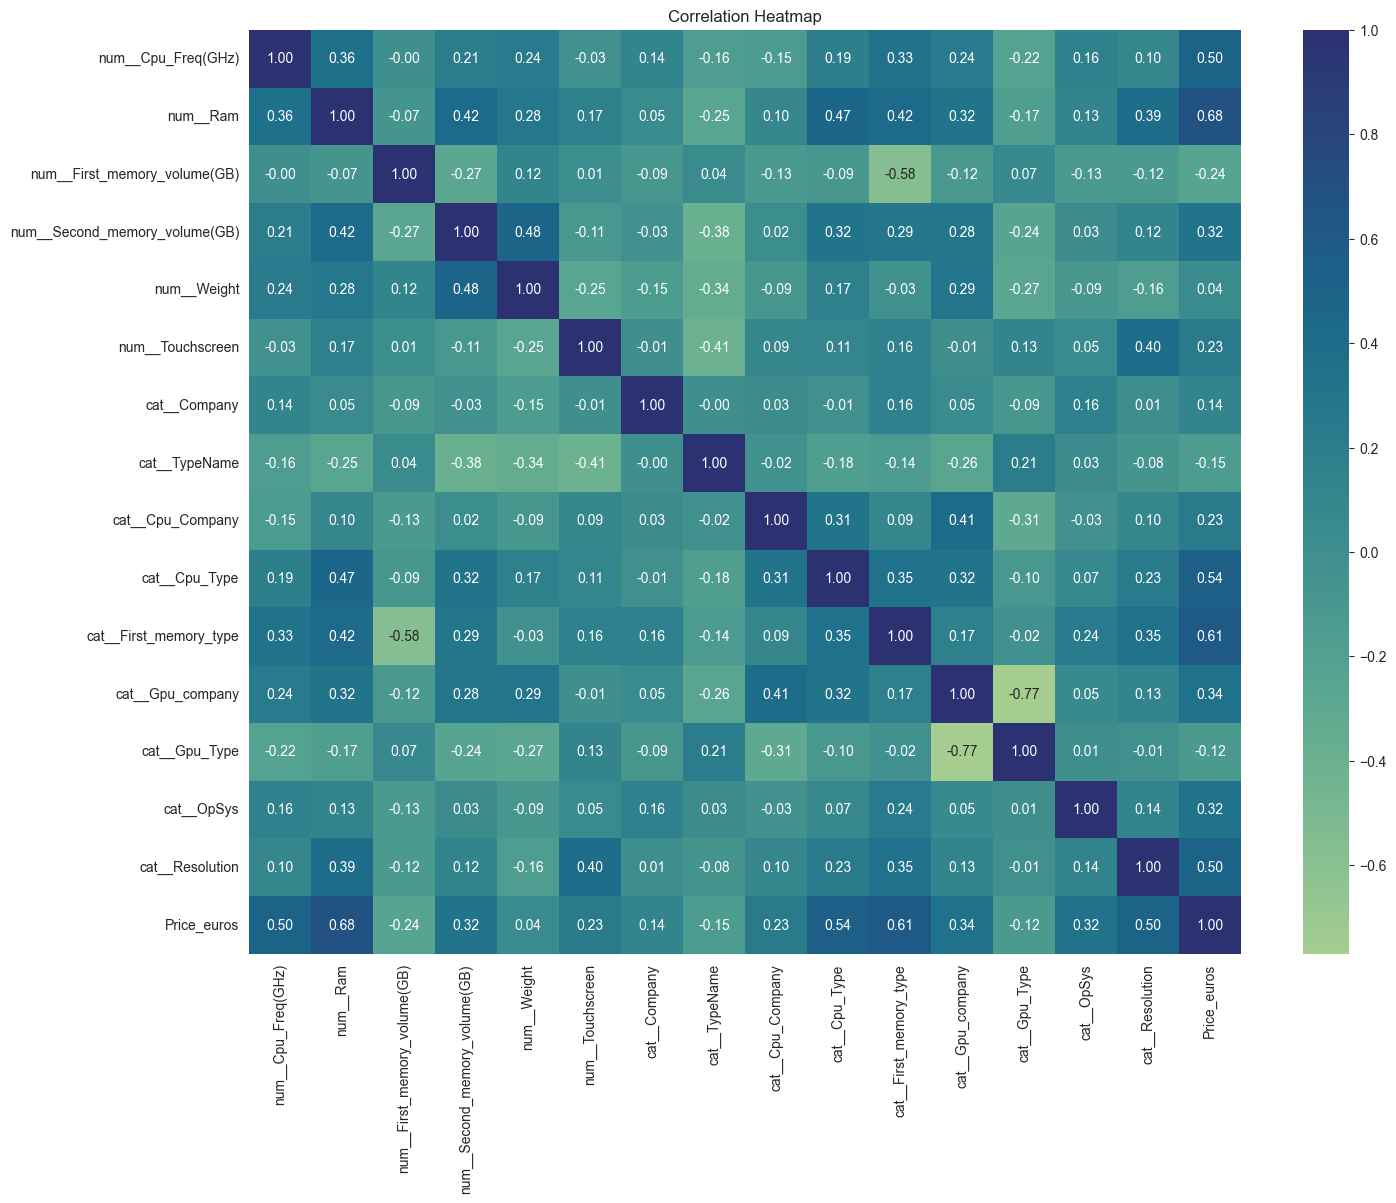

In [ ]:
correlation_matrix = x_train_preprocessed_df.corr()

# heatmap to see the relationships.
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# Select and train a model

In [ ]:
y_train = np.array(y_train).ravel()  # Flattening the target variable

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import cross_val_score
from sklearn import svm
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

-Training

In [ ]:
#Define models
models = {
    "Linear Regression": LinearRegression(),
    "SVM ":svm.SVR(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")

    # Train the model
    model.fit(x_train_preprocessed, y_train)

    # Predict on the training set
    y_train_pred = model.predict(x_train_preprocessed)

    # Calculate RMSE and R2 score on the training set
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    r2_train = r2_score(y_train, y_train_pred)

    results[name] = {"RMSE (Train)": rmse_train, "R2 Score (Train)": r2_train}

    # Display results
    print(f"{name}:")
    print(f"  RMSE (Train): {rmse_train:.4f}")
    print(f"  R2 Score (Train): {r2_train:.4f}")
    print("\n")

# Summary
print("Training Set Evaluation Summary:")
for name, metrics in results.items():
    print(f"{name}: RMSE (Train) = {metrics['RMSE (Train)']:.4f}, R2 Score (Train) = {metrics['R2 Score (Train)']:.4f}")


Training Linear Regression...
Linear Regression:
  RMSE (Train): 0.2849
  R2 Score (Train): 0.7635


Training SVM ...
SVM :
  RMSE (Train): 0.1622
  R2 Score (Train): 0.9233


Training Random Forest...
Random Forest:
  RMSE (Train): 0.0755
  R2 Score (Train): 0.9834


Training Set Evaluation Summary:
Linear Regression: RMSE (Train) = 0.2849, R2 Score (Train) = 0.7635
SVM : RMSE (Train) = 0.1622, R2 Score (Train) = 0.9233
Random Forest: RMSE (Train) = 0.0755, R2 Score (Train) = 0.9834


better evaluation using Cross validation


In [ ]:
# custom RMSE scorer
def rmse_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Create the scorer object
rmse_scorer_cv = make_scorer(rmse_scorer, greater_is_better=False)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "SVM ":svm.SVR(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# Dictionary to store results
results = {}

# Train and evaluate models
for name, model in models.items():
    print(f"Validating {name}...")

    # Cross-validation for RMSE
    cv_rmse = -cross_val_score(
        model,
        x_train_preprocessed,
        y_train,
        scoring=rmse_scorer_cv,
        cv=10
    ).mean()

    # Cross-validation for R2
    cv_r2 = cross_val_score(
        model,
        x_train_preprocessed,
        y_train,
        scoring='r2',
        cv=10
    ).mean()

    # Store results
    results[name] = {
        "RMSE (CV)": cv_rmse,
        "R2 Score (CV)": cv_r2
    }

    # Display individual model results
    print(f"{name}:")
    print(f"  RMSE (CV): {cv_rmse:.4f}")
    print(f"  R2 Score (CV): {cv_r2:.4f}")
    print("\n")

# Summary
print("Evaluation Summary:")
for name, metrics in results.items():
    print(f"{name}: RMSE (CV)= {metrics['RMSE (CV)']:.4f},R2 Score (CV) = {metrics['R2 Score (CV)']:.4f}")

Validating Linear Regression...
Linear Regression:
  RMSE (CV): 0.2899
  R2 Score (CV): 0.7508


Validating SVM ...
SVM :
  RMSE (CV): 0.2114
  R2 Score (CV): 0.8675


Validating Random Forest...
Random Forest:
  RMSE (CV): 0.2024
  R2 Score (CV): 0.8779


Evaluation Summary:
Linear Regression: RMSE (CV)= 0.2899,R2 Score (CV) = 0.7508
SVM : RMSE (CV)= 0.2114,R2 Score (CV) = 0.8675
Random Forest: RMSE (CV)= 0.2024,R2 Score (CV) = 0.8779


Although the random forest has clearly overfit the data we believe it is due to the low number of instances but Based on that and cross validation score, we will be using the random forest regressor hoping for better results on the test set after hyperparameter tuning

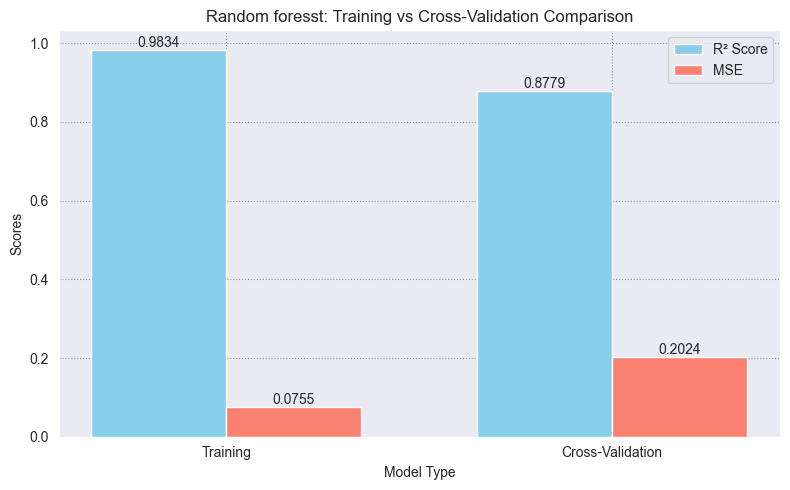

In [ ]:
labels = ['Training', 'Cross-Validation']
r2_scores_randomforest = [r2_train, cv_r2 ]
mse_scores_randomforest = [rmse_train, cv_rmse]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(labels))
width = 0.35
bars_r2_randomforest = ax.bar(x - width / 2, r2_scores_randomforest, width, label='R² Score', color='skyblue')
bars_mse_randomforest = ax.bar(x + width / 2, mse_scores_randomforest, width, label='MSE', color='salmon')

ax.set_xlabel('Model Type')
ax.set_ylabel('Scores')
ax.set_title('Random foresst: Training vs Cross-Validation Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def add_value_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.4f}', ha='center', va='bottom')

add_value_labels(bars_r2_randomforest)
add_value_labels(bars_mse_randomforest)

plt.tight_layout()
plt.show()

# hyperparameter tuning



Evaluation on testset before hyperparameter tuning the model

In [ ]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Use custom scoring for RMSE and R²
scoring = {
    'RMSE': 'neg_mean_squared_error',
    'R2': make_scorer(r2_score)
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scoring,
    refit='R2',
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Perform the grid search
print("Starting hyperparameter tuning...")
grid_search.fit(x_train_preprocessed, y_train)

# Extract best parameters, RMSE, and R²
best_params = grid_search.best_params_
best_rmse = np.sqrt(-grid_search.cv_results_['mean_test_RMSE'][grid_search.best_index_])  # Convert negative MSE to RMSE
best_r2 = grid_search.best_score_  # R² Score is directly available

print("\nBest Hyperparameters:")
print(best_params)

Starting hyperparameter tuning...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Hyperparameters:
{'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Final model = RandomForestRegressor

In [ ]:
# Initialize the model with the best hyperparameters
best_rf_model = RandomForestRegressor(
    bootstrap=True,
    max_depth=None,  # No limit on tree depth
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

# Fit the model on the full training dataset
best_rf_model.fit(x_train_preprocessed, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


-Test

In [ ]:
# Make predictions on the test set
y_pred = best_rf_model.predict(x_test_preprocessed)

# Calculate RMSE and R²
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test Set Performance: RMSE = {rmse:.4f}, R² = {r2:.4f}")


Test Set Performance: RMSE = 0.1941, R² = 0.8823


# Test on first instance

After choosing the Random Forest Regression as our final model.
let's predict the price of our first instance :)

In [ ]:
best_rf_model.fit(x_train_preprocessed, y_train)

# Create a DataFrame for the single sample
example_df = pd.DataFrame([['Apple', 'Ultrabook', 'Intel', 'Core i5', 2.3, 8, 128.0, 'SSD', 0.0,
                            'Intel', 'Iris Plus Graphics 640', 'macOS', 1.37, '2560x1600', 0.0]],
                          columns=['Company', 'TypeName', 'Cpu_Company', 'Cpu_Type', 'Cpu_Freq(GHz)',
                                   'Ram', 'First_memory_volume(GB)', 'First_memory_type', 'Second_memory_volume(GB)',
                                   'Gpu_company', 'Gpu_Type', 'OpSys', 'Weight', 'Resolution', 'Touchscreen'])
# Transform the example
example_preprocessed = preprocessor.transform(example_df)
y_pred = best_rf_model.predict(example_preprocessed)
predicted_price = int(np.exp(y_pred)[0])
print(f"The prdicted price: {predicted_price}$")
print(f"The original price of the laptop: 1340$")

The prdicted price: 1223$
The original price of the laptop: 1340$


The offset is only 87$ which is acceptable for a market like the Laptop market!